# EcoSort — Aperfeiçoamento do modelo (v5 ➜ v6)

Este notebook **NÃO treina do zero**. Ele parte do seu último modelo (`modelo_classificacao_v5/weights/best.pt`) e faz *fine-tuning* usando as **fotos reais da câmera do projeto**.

Objetivo: reduzir o viés de papelão equilibrando as classes, dando mais peso às fotos reais e usando recorte/zoom igual ao da lixeira.

> ⚠️ As classes precisam ser EXATAMENTE as mesmas do v5 (mesmos nomes de pasta). Há uma trava de segurança na seção 4 que verifica isso antes de treinar.

## 1 - Conectar com o Drive e montar a base do Kaggle

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install split-folders kagglehub ultralytics

import kagglehub
import shutil
import os

print("Baixando dataset base do Kaggle...")
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
print("Dataset baixado em:", path)

# Encontra a pasta com as categorias
pasta_classes = path
for root, dirs, files in os.walk(path):
    if 'metal' in dirs and 'paper' in dirs:
        pasta_classes = root
        break

# Bacia de mistura (Kaggle + suas fotos reais)
pasta_mistura_crua = '/content/dataset_12_classes/garbage_classification'

print(f"Copiando Kaggle para a bacia de mistura: {pasta_mistura_crua}")
shutil.copytree(pasta_classes, pasta_mistura_crua, dirs_exist_ok=True)

print("✅ Base do Kaggle pronta na bacia de mistura.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.2 MB/s eta 0:00:00
Baixando dataset base do Kaggle...
Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset baixado em: /kaggle/input/garbage-classification
Copiando Kaggle para a bacia de mistura: /content/dataset_12_classes/garbage_classification
✅ Base do Kaggle pronta na bacia de mistura.


## 2 - Faxina + equilíbrio das classes do Kaggle

Remove as 3 classes que não usamos (igual ao v5) e **limita quantas imagens do Kaggle cada classe pode ter**. Isso é feito ANTES de adicionar suas fotos, então suas fotos reais nunca são descartadas — só o excesso de estúdio é cortado, o que ajuda a tirar o papelão do trono.

In [2]:
import os, shutil, random

pasta_bacia = '/content/dataset_12_classes/garbage_classification'

# --- Faxina: tira as classes que o projeto não usa ---
classes_para_remover = ['clothes', 'shoes', 'battery']
print("🧹 Faxina nas classes...")
for classe in classes_para_remover:
    caminho = os.path.join(pasta_bacia, classe)
    if os.path.exists(caminho):
        shutil.rmtree(caminho)
        print(f"   ✅ '{classe}' removida.")
    else:
        print(f"   (aviso) '{classe}' não existia.")

# --- Equilíbrio: teto de imagens do Kaggle por classe ---
# Diminua este número para dar AINDA mais peso relativo às suas fotos reais.
MAX_KAGGLE_POR_CLASSE = 700
random.seed(42)

print(f"\n⚖️ Limitando o Kaggle a {MAX_KAGGLE_POR_CLASSE} imagens por classe...")
for classe in sorted(os.listdir(pasta_bacia)):
    p = os.path.join(pasta_bacia, classe)
    if not os.path.isdir(p):
        continue
    arqs = [f for f in os.listdir(p) if not f.startswith('.')]
    if len(arqs) > MAX_KAGGLE_POR_CLASSE:
        manter = set(random.sample(arqs, MAX_KAGGLE_POR_CLASSE))
        for f in arqs:
            if f not in manter:
                os.remove(os.path.join(p, f))
        print(f"   {classe}: {len(arqs)} -> {MAX_KAGGLE_POR_CLASSE}")
    else:
        print(f"   {classe}: {len(arqs)} (mantido)")

print("\n✅ Classes equilibradas.")

🧹 Faxina nas classes...
   ✅ 'clothes' removida.
   ✅ 'shoes' removida.
   ✅ 'battery' removida.

⚖️ Limitando o Kaggle a 700 imagens por classe...
   biological: 985 -> 700
   brown-glass: 607 (mantido)
   cardboard: 891 -> 700
   green-glass: 629 (mantido)
   metal: 769 -> 700
   paper: 1050 -> 700
   plastic: 865 -> 700
   trash: 697 (mantido)
   white-glass: 775 -> 700

✅ Classes equilibradas.


## 3 - Enriquecer com as fotos REAIS da câmera do projeto

Coloque suas fotos no Drive, **uma subpasta por classe**, com os mesmos nomes do modelo (ex.: `cardboard/`, `metal/`, `plastic/`...).

As fotos originais são preservadas e cada uma gera algumas variações leves (flip, rotação pequena, brilho, e de vez em quando um blur/ruído de câmera) para imitar a webcam. Como o YOLO já faz augmentation no treino, aqui o aumento é **moderado** de propósito.

In [4]:
import os, random, shutil
import numpy as np
import cv2
from PIL import Image, ImageEnhance

# 📂 AJUSTE AQUI: pasta no Drive com suas fotos reais (subpasta por classe).
# Guardar no Drive evita ter que re-subir as fotos a cada sessão do Colab.
pasta_suas_fotos = '/content/drive/MyDrive/EcoSort-datasets/dataset-ecosort'
pasta_bacia = '/content/dataset_12_classes/garbage_classification'

NUM_COPIAS = 10  # variações por foto real (moderado; o YOLO aumenta mais no treino)

if not os.path.isdir(pasta_suas_fotos):
    raise FileNotFoundError(
        f"Não encontrei '{pasta_suas_fotos}'.\n"
        "Crie essa pasta no Drive com uma subpasta por classe (cardboard/, metal/, ...) "
        "e coloque suas fotos reais dentro."
    )

def augmentar(img):
    img = img.convert('RGB')
    if random.choice([True, False]):
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    # rotação pequena (evita cortar muito o objeto)
    img = img.rotate(random.randint(-20, 20), expand=False)
    # brilho
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.6, 1.4))
    # ruído real de câmera (ocasional)
    arr = np.array(img)
    if random.random() < 0.3:
        arr = cv2.GaussianBlur(arr, (5, 5), 0)
    if random.random() < 0.3:
        ruido = np.random.normal(0, 10, arr.shape)
        arr = np.clip(arr + ruido, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

print("🧬 Gerando variações das fotos reais...\n")
total_reais = 0
for categoria in sorted(os.listdir(pasta_suas_fotos)):
    if categoria.startswith('.'):
        continue
    origem = os.path.join(pasta_suas_fotos, categoria)
    if not os.path.isdir(origem):
        continue

    destino = os.path.join(pasta_bacia, categoria)
    os.makedirs(destino, exist_ok=True)

    originais = [f for f in os.listdir(origem) if not f.startswith('.')]
    print(f"'{categoria}': {len(originais)} fotos reais")
    total_reais += len(originais)

    for nome in originais:
        try:
            base = Image.open(os.path.join(origem, nome))
            # 1) copia a ORIGINAL real para o dataset (sem mexer)
            base.convert('RGB').save(os.path.join(destino, f"real_{nome}.jpg"), 'JPEG')
            # 2) gera variações
            for i in range(NUM_COPIAS):
                augmentar(base).save(os.path.join(destino, f"real_{i}_{nome}.jpg"), 'JPEG')
        except Exception as e:
            print(f"   ❌ erro em {nome}: {e}")

print(f"\n✅ {total_reais} fotos reais incorporadas (com variações) ao dataset.")

🧬 Gerando variações das fotos reais...

'metal': 28 fotos reais
'paper': 74 fotos reais
'plastic': 90 fotos reais

✅ 192 fotos reais incorporadas (com variações) ao dataset.


## 4 - Montar treino/validação + TRAVA DE SEGURANÇA das classes

Divide em treino/validação e confere se as classes do dataset batem **exatamente** com as do modelo v5. Se não baterem, o fine-tuning não faz sentido (a cabeça de classificação não encaixa) e o notebook para aqui.

In [5]:
import os
import splitfolders
from ultralytics import YOLO

MODELO_ANTERIOR = '/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v5/weights/best.pt'
pasta_bacia = '/content/dataset_12_classes/garbage_classification'
pasta_pronta = '/content/dataset_finetune_v6'

print("⏳ Dividindo em treino/validação...")
splitfolders.ratio(pasta_bacia, output=pasta_pronta, seed=42, ratio=(0.8, 0.2))
print(f"✅ Dataset pronto em: {pasta_pronta}\n")

# --- TRAVA: as classes do dataset precisam ser as mesmas do modelo v5 ---
classes_dataset = sorted(
    d for d in os.listdir(os.path.join(pasta_pronta, 'train'))
    if os.path.isdir(os.path.join(pasta_pronta, 'train', d))
)
modelo_v5 = YOLO(MODELO_ANTERIOR)
classes_modelo = sorted(modelo_v5.names.values())

print("Classes do modelo v5:", classes_modelo)
print("Classes do dataset :", classes_dataset)

if classes_dataset != classes_modelo:
    faltando = set(classes_modelo) - set(classes_dataset)
    sobrando = set(classes_dataset) - set(classes_modelo)
    raise ValueError(
        "As classes NÃO batem com o modelo v5.\n"
        f"Faltando no dataset: {faltando}\n"
        f"Sobrando no dataset: {sobrando}\n"
        "Corrija os nomes das subpastas das suas fotos reais e rode de novo."
    )

print("\n✅ Classes batem com o v5. Pode treinar com segurança.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ Dividindo em treino/validação...


Copying files: 8245 files [00:01, 7670.11 files/s]


✅ Dataset pronto em: /content/dataset_finetune_v6

Classes do modelo v5: ['biological', 'brown-glass', 'cardboard', 'green-glass', 'metal', 'paper', 'plastic', 'trash', 'white-glass']
Classes do dataset : ['biological', 'brown-glass', 'cardboard', 'green-glass', 'metal', 'paper', 'plastic', 'trash', 'white-glass']

✅ Classes batem com o v5. Pode treinar com segurança.


## 5 - Fine-tuning (continuar a partir do v5)

Aqui está o ponto central: carregamos o `best.pt` do **v5** como ponto de partida (não o `yolov8n-cls.pt` genérico) e continuamos o treino. Usamos **learning rate menor** (`lr0=0.001`) e **menos épocas** para aperfeiçoar sem destruir o que o modelo já aprendeu.

`scale` e `erasing` ajustados conforme combinamos: zoom moderado e *erasing* mais baixo, para não transformar tudo em textura marrom (gasolina pro viés de papelão).

In [7]:
from ultralytics import YOLO

MODELO_ANTERIOR = '/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v5/weights/best.pt'
pasta_pronta = '/content/dataset_finetune_v6'

# Carrega o SEU modelo treinado como ponto de partida (fine-tuning, não do zero)
model = YOLO(MODELO_ANTERIOR)

# --- FREEZE (congelar camadas) ---
# Congela as N primeiras camadas: elas NÃO atualizam os pesos durante o treino.
# As primeiras camadas reconhecem coisas genéricas (bordas, texturas, cores) e já
# estão boas vindas de milhares de imagens — congelá-las protege esse aprendizado
# e evita overfitting quando você tem poucas fotos reais. Só as camadas finais
# (a "decisão" de qual classe) continuam aprendendo com suas fotos reais.
#
# Como ajustar (yolov8n-cls tem ~30 camadas no total):
#   - POUCAS fotos reais (dezenas por classe): freeze=10  <- padrão seguro
#   - MUITAS fotos reais (centenas por classe): freeze=4  ou  freeze=0 (mais liberdade)
#   - Congelar demais (12+) = super seguro, mas pouca adaptacao ao mundo real
#   - Congelar de menos (0) = adapta mais, mas arrisca 'esquecer' o Kaggle
# Dica: treine com dois valores e compare a acuracia de validacao + o teste nas fotos reais.
FREEZE = 5

print(f"\U0001F680 Iniciando fine-tuning (v5 \u279c v6) com freeze={FREEZE}...")
model.train(
    data=pasta_pronta,
    epochs=80,
    patience=20,
    imgsz=224,
    device=0,
    project='/content/drive/MyDrive/EcoSort_Modelos',
    name='modelo_classificacao_v6',
    lr0=0.001,          # LR baixo: aperfeicoa sem 'esquecer' o aprendido
    warmup_epochs=2,
    freeze=FREEZE,      # congela as N primeiras camadas (veja o comentario acima)
    # augmentation
    scale=0.5,          # zoom/crop moderado
    erasing=0.2,        # mais baixo p/ nao virar mancha marrom
    hsv_v=0.4,
    hsv_s=0.3,
    fliplr=0.5,
)
print("\n\u2705 Fine-tuning concluido. Pesos em .../modelo_classificacao_v6/weights/best.pt")

🚀 Iniciando fine-tuning (v5 ➜ v6) com freeze=5...
Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_finetune_v6, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v5/weights/best.pt, momentum=0.937, mosaic=1.0,

## 6 - Testar o v6 (com recorte central + limiar)

O teste imita o deployment: recorta o centro (zoom natural, igual à lixeira) e só aceita o resultado se a confiança passar do limiar. Em classificação o `conf` do `predict` **não** filtra sozinho — por isso o filtro é manual aqui.

Faça o upload de uma imagem:


Saving GARRAFA_CACULA_300ML-528x528.jpg to GARRAFA_CACULA_300ML-528x528.jpg

--- RESULTADO ---
Classe: BROWN-GLASS  |  Certeza: 100.00%
{
  "lixeira_id": "smart_bin_01",
  "timestamp": "2026-06-24T18:07:46.793718+00:00",
  "detection": {
    "class_name": "brown-glass",
    "confidence": 1.0
  }
}


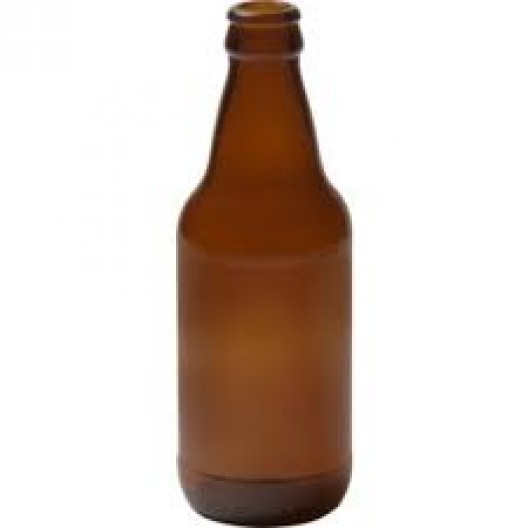

In [10]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import IPython.display as display
import json
from datetime import datetime, timezone

caminho_do_modelo = '/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v6-2/weights/best.pt'
LIMIAR = 0.75  # softmax é superconfiante; comece alto e ajuste

modelo_treinado = YOLO(caminho_do_modelo)

# def zoom_central(img, fracao=0.6):
#     w, h = img.size
#     lado = int(min(w, h) * fracao)
#     e = (w - lado) // 2
#     t = (h - lado) // 2
#     return img.crop((e, t, e + lado, t + lado))

print("Faça o upload de uma imagem:")
uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    caminho_imagem = f"/content/{nome_arquivo}"
    img = Image.open(caminho_imagem).convert('RGB')
    # img_zoom = zoom_central(img, fracao=0.6)

    resultados = modelo_treinado.predict(source=img, save=False, verbose=False)
    for resultado in resultados:
        idx = resultado.probs.top1
        nome_da_classe = resultado.names[idx]
        certeza = resultado.probs.top1conf.item()

        print("\n--- RESULTADO ---")
        if certeza >= LIMIAR:
            print(f"Classe: {nome_da_classe.upper()}  |  Certeza: {certeza*100:.2f}%")
            payload = {
                "lixeira_id": "smart_bin_01",
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "detection": {"class_name": nome_da_classe, "confidence": round(certeza, 4)},
            }
            print(json.dumps(payload, indent=2))
        else:
            print(f"INCONCLUSIVO: {nome_da_classe} a {certeza*100:.2f}% (abaixo de {LIMIAR*100:.0f}%).")

        display.display(img)

## 7 - Exportar o v6 para NCNN (Raspberry Pi)

In [11]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v6-2/weights/best.pt')

# NCNN otimizado para ARM/Raspberry Pi
model.export(format='ncnn')
print("✅ Exportado. Lembre de apontar o MODEL_PATH do código da lixeira para o novo best_ncnn_model do v6.")

Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-cls summary (fused): 30 layers, 1,446,409 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/EcoSort_Modelos/modelo_classificacao_v6-2/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 9) (2.8 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 382ms
Prepared 1 package in 154ms
Installed 1 package in 3ms
 + ncnn==1.0.20260526

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 30 packages i